# Getting Started with pandas
Pandas digunakan untuk analisis dan manipulasi suatu data di python, terutama data berbentuk tabel(exel, csv, sql, dll) atau bisa juga disebut data heterogeneous.

In [43]:
# sebagai penyederhanaan kita akan selalu:
import pandas as pd # disini pandas disingkat pd
import numpy as np 

## Introduction to pandas Data Structures
Pandas memilki 2 struktur data utama: series dan dataframe.

### Series
#### Series adalah struktur data mirip array satu dimensi yang mirip dengan dictionary, karena memiliki index(key) dan value. Walaupun mirip array, ia bisa menampung data yang lebih fleksibel.

In [ ]:
# series paling sederhana hanya berupa array data
obj = pd.Series([3, -6, 5, 8])
print(obj) # akan memberi indeks dan nilai dan tipe data dari series tersebut
# index defaultnya adalah 0,1,2,3,...,n-1

# bila kita ingin hanya meihat bentuk arraynya
print(obj.array) # akan menampilkan arraynya saja
# atau PEMBENTUK indexnya saja
print(obj.index) # akan menampilkan indexnya saja

0    3
1   -6
2    5
3    8
dtype: int64
<NumpyExtensionArray>
[3, -6, 5, 8]
Length: 4, dtype: int64
RangeIndex(start=0, stop=4, step=1)


In [8]:
# misal kita ingin memberi index sendiri, kita bisa menentukannya saat membuat series
obj2 = pd.Series([3, -6, 5, 8], index=['a', 'b', 'c', 'd'])
print(obj2)
# bila kita ingin mengambil satu atau beberapa nilai, kita cukup menggunakan label indexnya
print(obj2['a'])
# atau kita ingin mengganti nilai(slice) tertentu, kita bisa menggunakan label indexnya
obj2['c'] = 7
print(obj2[['a', 'b', 'c']]) # akan menampilkan nilai dari index a,b,c

a    3
b   -6
c    5
d    8
dtype: int64
3
a    3
b   -6
c    7
dtype: int64


In [9]:
# menggunakan fungsi atau operasi dari numpy akan tetap menjaga koneksi index-value
print(obj2[obj2 > 0]) # akan menampilkan nilai yang lebih besar dari 0, hasil tetap index-value
print(np.exp(obj2)) # akan menampilkan nilai dari e^x dari setiap value,hasil tetap index-value

a    3
c    7
d    8
dtype: int64
a      20.085537
b       0.002479
c    1096.633158
d    2980.957987
dtype: float64


In [ ]:
# karena bentuknya mirip dictionary, kita bisa membuat series dari dictionary ataupun sebaliknya
# misal kita punya suatu data dictionary
sdata = {'jakarta': 12500, 'bogor': 6600, 'depok': 2100, 'tangerang': 6500, 'bekasi': 2600}
# untuk mengubah ke pandas series:
obj3 = pd.Series(sdata)
print("dictionary ke series")
print(obj3) # akan menampilkan index dan value dari series tersebut

# atau ingin sebaliknya:
print("series ke dictionary")
print(obj3.to_dict()) # akan menampilkan dictionary dari series tersebut

# misal kita ingin mengganti indexnya
kota = ['bandung', 'bogor', 'depok', 'tangerang', 'bekasi']
obj4 = pd.Series(sdata, index=kota) # akan menampilkan series dengan index kota
print(obj4) # akan menampilkan index dan value dari series tersebut, karena data tidak ada maka akan nan


dictionary ke series
jakarta      12500
bogor         6600
depok         2100
tangerang     6500
bekasi        2600
dtype: int64
series ke dictionary
{'jakarta': 12500, 'bogor': 6600, 'depok': 2100, 'tangerang': 6500, 'bekasi': 2600}
bandung         NaN
bogor        6600.0
depok        2100.0
tangerang    6500.0
bekasi       2600.0
dtype: float64


In [16]:
# data hilang biasa disebut missing, NA, atau null, ketiga sebutan bisa digunakan secara bergantian
# misal kita ingin mencari data yang hilang, bisa dengan isna() atau notna()
print("data hilang")
print(obj4.isna()) # akan menampilkan True bila data hilang, False bila ada
print(obj4.notna()) # akan menampilkan True bila data ada, False bila hilang

# bila dengan null, sama saja, bisa dengan isnull() atau notnull()
print("data hilang")
print(obj4.isnull()) # akan menampilkan True bila data hilang, False bila ada
print(obj4.notnull()) # akan menampilkan True bila data ada, False bila hilang

data hilang
bandung       True
bogor        False
depok        False
tangerang    False
bekasi       False
dtype: bool
bandung      False
bogor         True
depok         True
tangerang     True
bekasi        True
dtype: bool
data hilang
bandung       True
bogor        False
depok        False
tangerang    False
bekasi       False
dtype: bool
bandung      False
bogor         True
depok         True
tangerang     True
bekasi        True
dtype: bool


In [ ]:
# salahsatu aplikasi berguna adalah, operasi aritmatika antar series langsung dilakukan berdasarkan indexnya
# fitur ini disebut data alignment, bila indexnya tidak sama maka akan menghasilkan data hilang(nan)
print("operasi aritmatika antar series")
print(obj3 + obj4) # akan menampilkan hasil penjumlahan dari dua series berdasarkan indexnya
print(obj3 - obj4) # akan menampilkan hasil pengurangan dari dua series berdasarkan indexnya
print(obj3 * obj4) # akan menampilkan hasil perkalian dari dua series berdasarkan indexnya

operasi aritmatika antar series
bandung          NaN
bekasi        5200.0
bogor        13200.0
depok         4200.0
jakarta          NaN
tangerang    13000.0
dtype: float64
bandung      NaN
bekasi       0.0
bogor        0.0
depok        0.0
jakarta      NaN
tangerang    0.0
dtype: float64
bandung             NaN
bekasi        6760000.0
bogor        43560000.0
depok         4410000.0
jakarta             NaN
tangerang    42250000.0
dtype: float64


In [18]:
# kita juga bisa memberi atribut pada index dan value dengan metode .name
obj3.name = 'jumlah penduduk' # memberi nama value
obj3.index.name = 'kota' # memberi nama index

print("atribut nama index dan value")
print(obj3) # akan menampilkan nama value dan nama index pada series tersebut

atribut nama index dan value
kota
jakarta      12500
bogor         6600
depok         2100
tangerang     6500
bekasi        2600
Name: jumlah penduduk, dtype: int64


### DataFrame
#### Bisa dibilang sebagai higher order dari series, karena dataframe adalah kumpulan series yang di sejajarkan karena berbagi index
#### ini bentuk data yang paling umum digunakan di pandas, karena bisa menampung data heterogen, dan bisa menampung data yang lebih kompleks.

In [20]:
# cara paling sering membuat dataframe adalah dari dictionary yang berisi list sama panjang atau dengan array numpy
data = {"kota": ['jakarta', 'jakarta', 'jakarta', 'bogor', 'bogor', 'bogor'],
        "tahun": [2020, 2021, 2022, 2023, 2024, 2025],
        "populasi": [12500, 12600, 12700, 6600, 6700, 6800]}
frame = pd.DataFrame(data) # mengubah data dictionary ke dataframe
print("dataframe dari dictionary")
print(frame)

# untuk dataframe yang besar, kita bisa menampilkan 5 baris pertama dengan head() dan 5 baris terakhir dengan tail()
print("5 baris pertama")
print(frame.head()) # menampilkan 5 baris pertama
print("5 baris terakhir")
print(frame.tail()) # menampilkan 5 baris terakhir

dataframe dari dictionary
      kota  tahun  populasi
0  jakarta   2020     12500
1  jakarta   2021     12600
2  jakarta   2022     12700
3    bogor   2023      6600
4    bogor   2024      6700
5    bogor   2025      6800
5 baris pertama
      kota  tahun  populasi
0  jakarta   2020     12500
1  jakarta   2021     12600
2  jakarta   2022     12700
3    bogor   2023      6600
4    bogor   2024      6700
5 baris terakhir
      kota  tahun  populasi
1  jakarta   2021     12600
2  jakarta   2022     12700
3    bogor   2023      6600
4    bogor   2024      6700
5    bogor   2025      6800


In [30]:
# kita juga bisa mengatur kolum dengan mengubah urutan kolomnya
frame2 = pd.DataFrame(data, columns=["tahun", "kota", "populasi"]) # mengubah urutan kolom
print("dataframe dengan urutan kolom diubah")
print(frame2) # menampilkan dataframe dengan urutan kolom diubah
# bila kita memberi kolum yang tida ada di data awal, maka akan menghasilkan kolum baru dengan nilai nan
frame3 = pd.DataFrame(data, columns=["tahun", "kota", "populasi", "utang"]) # menambahkan kolom baru
print("\ndataframe dengan kolom baru")
print(frame3) # menampilkan dataframe dengan kolom baru
# column data juga bisa ditarik dan akan menjadi series
print("\nkolom 'tahun' sebagai series")
print(frame2["tahun"]) # menampilkan kolom 'tahun' sebagai series

# atau dengan .kolum, misal kita ingin menampilkan kolom 'kota'
print("\nkolom 'kota' sebagai series")
print(frame2.kota) # menampilkan kolom 'kota' sebagai series

# bentuk series indexnya disesuaikan dengan dataframe, dan names nya sesuai dengan nama kolomnya
# perlu diketahui penggunaan dataframe.kolom memiliki 2 syarat
# 1. nama kolom harus object python valid
# 2. nama kolom tidak boleh sama dengan method dataframe
# bila tidak memenuhi 2 syarat harus menggunakan dataframe['kolom'] untuk mengakses kolomnya

dataframe dengan urutan kolom diubah
   tahun     kota  populasi
0   2020  jakarta     12500
1   2021  jakarta     12600
2   2022  jakarta     12700
3   2023    bogor      6600
4   2024    bogor      6700
5   2025    bogor      6800

dataframe dengan kolom baru
   tahun     kota  populasi utang
0   2020  jakarta     12500   NaN
1   2021  jakarta     12600   NaN
2   2022  jakarta     12700   NaN
3   2023    bogor      6600   NaN
4   2024    bogor      6700   NaN
5   2025    bogor      6800   NaN

kolom 'tahun' sebagai series
0    2020
1    2021
2    2022
3    2023
4    2024
5    2025
Name: tahun, dtype: int64

kolom 'kota' sebagai series
0    jakarta
1    jakarta
2    jakarta
3      bogor
4      bogor
5      bogor
Name: kota, dtype: str


In [ ]:
# bila ingin mengambil baris(row) tertentu, bisa dengan .loc[] atau .iloc[]
# kita ingin mengambil baris ke-3 dengan loc[]
print("baris ke-3 dengan loc[]")
print(frame2.loc[3])

# atau dengan iloc[] untuk mengambil baris ke-3
print("\nbaris ke-3 dengan iloc[]")
print(frame2.iloc[3])

baris ke-3 dengan loc[]
tahun        2023
kota        bogor
populasi     6600
Name: 3, dtype: object

baris ke-3 dengan iloc[]
tahun        2023
kota        bogor
populasi     6600
Name: 3, dtype: object


In [32]:
# colum bisa diganti isinya dengan assigment, misal kita ingin mengisi nilai kolom 'utang' dengan '17'
frame3['utang'] = 17 # mengisi kolom
print("dataframe dengan kolom 'utang' diisi")
print(frame3) # menampilkan dataframe dengan kolom 'utang' diisi
# atau bisa juga dengan nilai array
print("\ndataframe dengan kolom 'utang' diisi dengan array")
frame3['utang'] = np.arange(6) # mengisi kolom dengan array
print(frame3) # menampilkan dataframe dengan kolom 'utang' diisi dengan array

dataframe dengan kolom 'utang' diisi
   tahun     kota  populasi  utang
0   2020  jakarta     12500     17
1   2021  jakarta     12600     17
2   2022  jakarta     12700     17
3   2023    bogor      6600     17
4   2024    bogor      6700     17
5   2025    bogor      6800     17

dataframe dengan kolom 'utang' diisi dengan array
   tahun     kota  populasi  utang
0   2020  jakarta     12500      0
1   2021  jakarta     12600      1
2   2022  jakarta     12700      2
3   2023    bogor      6600      3
4   2024    bogor      6700      4
5   2025    bogor      6800      5


In [ ]:
# kita juga bisa meremove column dengan del, misal kita ingin menghapus kolom 'utang'
del frame3['utang'] # menghapus kolom 'utang'
print("\ndataframe dengan kolom 'utang' dihapus")
print(frame3) # menampilkan dataframe dengan kolom 'utang' dihapus
# perlu diingat, bila kita indexing koom, itu akan menjadi view


dataframe dengan kolom 'utang' dihapus
   tahun     kota  populasi
0   2020  jakarta     12500
1   2021  jakarta     12600
2   2022  jakarta     12700
3   2023    bogor      6600
4   2024    bogor      6700
5   2025    bogor      6800


In [37]:
# bentuk data lain yang juga umum adalah nested dict of dict
populasi = {'jakarta': {2020: 12500, 2021: 12600, 2022: 12700, 2023: 12800},
            'bogor': {2021: 6700, 2022: 6800, 2023: 6900}}
frame4 = pd.DataFrame(populasi) # outer dict otomatis menjadi kolom jika dikonversi ke dataframe
print("nested dict of dict ke dataframe")
print(frame4) # menampilkan dataframe dari nested dict of dict

# kita juga bisa mentranspose dataframe dengan .T, misal kita ingin mentranspose frame4
print("\ndataframe transpos")
print(frame4.T) # kolom menjadi index dan index menjadi kolom
# trnaspose membuang tipe data jika kolom tidak homogen, sehingga tipe data akan menjadi object

# bentuk nested diatas tidak berlaku jika kita mendetailkan indexnya
print(pd.DataFrame(populasi, index=[2020, 2021, 2023])) # baris yang tidak ada di data akan menjadi nan



nested dict of dict ke dataframe
      jakarta   bogor
2020    12500     NaN
2021    12600  6700.0
2022    12700  6800.0
2023    12800  6900.0

dataframe transpos
            2020     2021     2022     2023
jakarta  12500.0  12600.0  12700.0  12800.0
bogor        NaN   6700.0   6800.0   6900.0
      jakarta   bogor
2020    12500     NaN
2021    12600  6700.0
2023    12800  6900.0


In [38]:
# dictionary berisi series juga akan di treat dengan cara yang sama:
pdata2 = {"jakarta": frame4['jakarta'][:-2],
           "bogor": frame4['bogor'][:2]} # mengambil series dari dataframe
print("dictionary berisi series ke dataframe")
print(pd.DataFrame(pdata2)) # menampilkan dataframe dari dictionary berisi series

dictionary berisi series ke dataframe
      jakarta   bogor
2020    12500     NaN
2021    12600  6700.0


#### Berikut macam data input yang bisa digunakan untuk membuat dataframe:
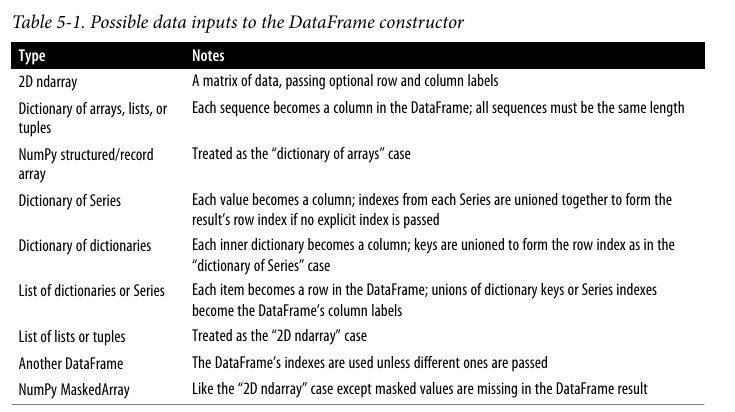

In [46]:
# dengan meotde dataframe to numpy, akan memunculkan array 2 dimensi
print("dataframe ke array 2 dimensi")
print(frame4.to_numpy()) # akan menampilkan array 2 dimensi dari dataframe

# Tetapi, jika kolomnya heterogen, maka akan menjadi array object
print("\ndataframe heterogen ke array object")
print(frame3.to_numpy()) # akan menampilkan array object dari dataframe heterogen

dataframe ke array 2 dimensi
[[12500.    nan]
 [12600.  6700.]
 [12700.  6800.]
 [12800.  6900.]]

dataframe heterogen ke array object
[[2020 'jakarta' 12500]
 [2021 'jakarta' 12600]
 [2022 'jakarta' 12700]
 [2023 'bogor' 6600]
 [2024 'bogor' 6700]
 [2025 'bogor' 6800]]


### Index Objects
#### index objects berfungsi menyimpan label axis (kolom pada dataframe, index pada series)
##### memiliki 2 karakteristik utama:
1. Immutable: tidak bisa diubah setelah dibuat
2. bersifat seperti set yang bisa di duplikasi

In [48]:
obj = pd.Series(range(5), index=['a', 'b', 'c', 'd', 'e']) # membuat series dengan index a,b,c,d,e
index = obj.index # mengambil index dari series
print("index dari series")
print(index) # menampilkan index dari series

index dari series
Index(['a', 'b', 'c', 'd', 'e'], dtype='str')


In [49]:
# ingat, index bersifat immutable, sehingga tidak bisa diubah setelah dibuat
index[1] = 'z' # akan error karena index bersifat immutable

TypeError: Index does not support mutable operations

In [50]:
# immutable membuat ini lebih aman untuk membagikan index object ke struktur data lain, karena tidak bisa diubah setelah dibuat
labels =pd.Index(np.arange(5)) # membuat index dari array 0,1,2,3,4
obj2 = pd.Series([1.6, 2.5, 3.7, 4.1, 5.9], index=labels) # membuat series dengan index labels
print("series dengan index immutable")
print(obj2) # menampilkan series dengan index immutable
print(obj2.index is labels) # akan menampilkan True karena index dari series sama dengan labels

series dengan index immutable
0    1.6
1    2.5
2    3.7
3    4.1
4    5.9
dtype: float64
True


In [51]:
# index panda karena seperti set, maka bisa memiliki label duplikasi
pd.Index(['foo', 'foo', 'bar', 'bar']) # akan menampilkan index dengan label duplikasi

Index(['foo', 'foo', 'bar', 'bar'], dtype='str')

#### Berikut beberapa properti dan method yang bisa digunakan pada index object:
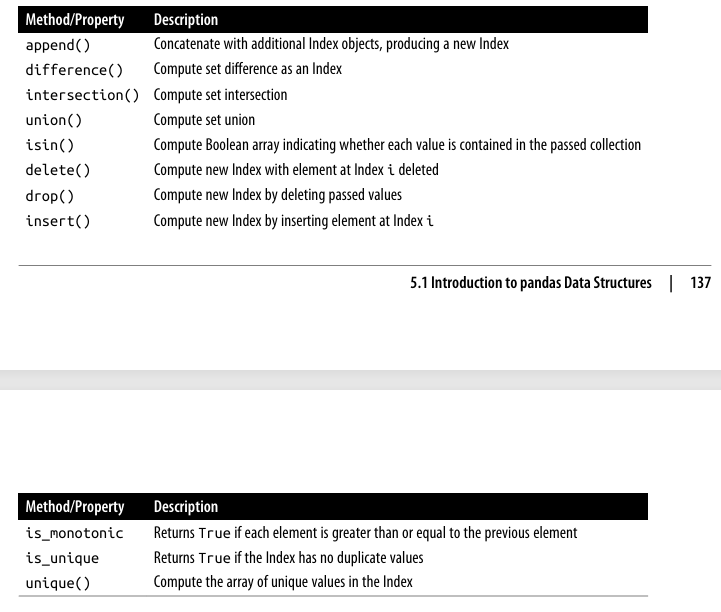

## Essential Functionality
### Disini kita akan belajar mekanika interaksi dasar dengan series atau dataframe

### Reindexing
#### teknik ini bekerja dengan membuat sebuah objek baru lalu data yang sudah ada diatur ulang sesuai objek baru tersebut

In [53]:
# pemakaian sederhananya
obj = pd.Series([1.5, -2.5, 0, 3.7], index=['a', 'b', 'c', 'd'])
# lalu kita reindex
obj2 = obj.reindex(['a', 'b', 'c', 'd', 'e']) # akan menampilkan series dengan index baru, bila index baru tidak ada maka akan nan
print("series setelah reindexing")
print(obj2) # menampilkan series setelah reindexing

series setelah reindexing
a    1.5
b   -2.5
c    0.0
d    3.7
e    NaN
dtype: float64


In [55]:
# untuk beberapa jenis data, mungkin kita ingin mengisi data hilang dengan nilai tertentu, kita bisa gunakan ffill
waktu = pd.Series(pd.date_range('2024-01-01', periods=6, freq='D')) # membuat range waktu 6 hari
obj3 = waktu.reindex(np.arange(10), method='ffill') # bila index baru tidak ada, maka akan diisi dengan nilai terakhir yang ada
print("series setelah reindexing dengan ffill")
print(obj3) # menampilkan series setelah reindexing dengan ffill

series setelah reindexing dengan ffill
0   2024-01-01
1   2024-01-02
2   2024-01-03
3   2024-01-04
4   2024-01-05
5   2024-01-06
6   2024-01-06
7   2024-01-06
8   2024-01-06
9   2024-01-06
dtype: datetime64[us]


In [59]:
# dengan dataframe, reindex bisa mengubah index(baris), kolom, atau keduanya
frame = pd.DataFrame(np.arange(25).reshape((5,5)),
                     index=(['a', 'c', 'd', 'e', 'f']),
                     columns=(['jakarta', 'bogor', 'depok', 'tangerang', 'bekasi']))
print("dataframe awal")
print(frame) # menampilkan dataframe awal

frame2 = frame.reindex(index= ['a', 'b', 'c', 'd', 'e', 'f']) # akan menampilkan dataframe dengan index baru
print("\ndataframe setelah reindexing index")
print(frame2) # menampilkan dataframe setelah reindexing index

dataframe awal
   jakarta  bogor  depok  tangerang  bekasi
a        0      1      2          3       4
c        5      6      7          8       9
d       10     11     12         13      14
e       15     16     17         18      19
f       20     21     22         23      24

dataframe setelah reindexing index
   jakarta  bogor  depok  tangerang  bekasi
a      0.0    1.0    2.0        3.0     4.0
b      NaN    NaN    NaN        NaN     NaN
c      5.0    6.0    7.0        8.0     9.0
d     10.0   11.0   12.0       13.0    14.0
e     15.0   16.0   17.0       18.0    19.0
f     20.0   21.0   22.0       23.0    24.0


In [61]:
# kita bisa reindex kolom dengan cara yang sama, misal kita ingin menambahkan kolom baru 'bandung'
frame3 = frame.reindex(columns= ['jakarta', 'bogor', 'depok', 'tangerang', 'bekasi', 'bandung']) # akan menampilkan dataframe dengan kolom baru
print("\ndataframe setelah reindexing kolom")
print(frame3) # menampilkan dataframe setelah reindexing kolom

# atau cara lain dengan axis keyword
print("\ndataframe setelah reindexing kolom dengan axis keyword")
frame4 = frame.reindex(['jakarta', 'bogor', 'depok', 'tangerang', 'bekasi', 'bandung'], axis="columns") # akan menampilkan dataframe dengan kolom baru
print(frame4)


dataframe setelah reindexing kolom
   jakarta  bogor  depok  tangerang  bekasi  bandung
a        0      1      2          3       4      NaN
c        5      6      7          8       9      NaN
d       10     11     12         13      14      NaN
e       15     16     17         18      19      NaN
f       20     21     22         23      24      NaN

dataframe setelah reindexing kolom dengan axis keyword
   jakarta  bogor  depok  tangerang  bekasi  bandung
a        0      1      2          3       4      NaN
c        5      6      7          8       9      NaN
d       10     11     12         13      14      NaN
e       15     16     17         18      19      NaN
f       20     21     22         23      24      NaN


#### Berikut argumen fungsi lebih lengkap untuk reindexing:
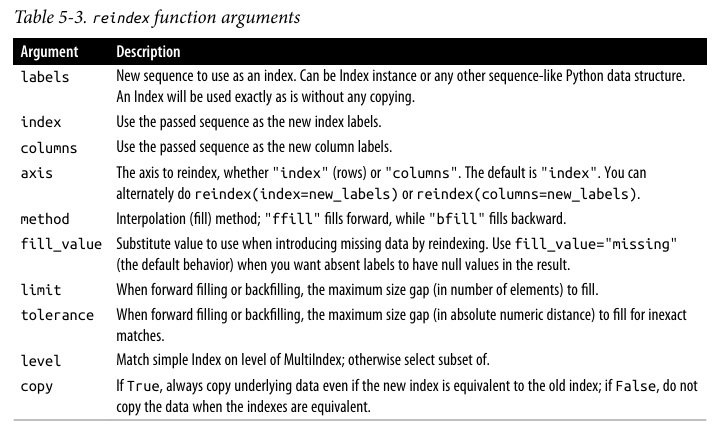

### Dropping Entries from an Axis
#### teknik ini digunakan untuk menghapus 1 atau lebih entry data(series atau dataframe), dengan metode drop()

In [ ]:
# mengunakan reindexing atau loc akan memakan waktu lebih lama dibandingkan dengan drop
# karena reindexing membuat objek baru, sedangkan drop menghapus entry dari objek yang sudah ada

obj = pd.Series(np.arange(8), index=['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h'])
print("series awal")
print(obj) # menampilkan series awal
new_obj = obj.drop(['a', 'h'])
print("\nseries setelah drop index 'a' dan 'h'")
print(new_obj) # menampilkan series setelah drop index 'a' dan 'h'

series awal
a    0
b    1
c    2
d    3
e    4
f    5
g    6
h    7
dtype: int64

series setelah drop index 'a' dan 'h'
b    1
c    2
d    3
e    4
f    5
g    6
dtype: int64


In [67]:
# bila dengan dataframe, index value bisa dihapus dari 2 axis(ingat axis=0 untuk baris, axis=1 untuk kolom)
data = pd.DataFrame(np.arange(25).reshape((5,5)),
                    index=(['jakarta', 'bogor', 'depok', 'tangerang', 'bekasi']),
                    columns = (['tahun', 'populasi', 'utang', 'pendapatan', 'pengeluaran']))
print("dataframe awal")
print(data) # menampilkan dataframe awal

# drop diikuti urutan label akan menghapus baris
print("\ndataframe setelah drop baris 'jakarta' dan 'bekasi'")
print(data.drop(['jakarta', 'bekasi'])) # menampilkan dataframe setelah drop baris

# bila ingin kolom yang dihapus, gunakan keyword columns
print("\ndataframe setelah drop kolom 'utang' dan 'pendapatan'")
print(data.drop(columns=['utang', 'pendapatan'])) # menampilkan dataframe setelah drop kolom

# atau dengan syntax numeric, axis=1 untuk kolom
print("\ndataframe setelah drop kolom 'utang' dan 'pendapatan' dengan axis=1")
print(data.drop(['utang', 'pendapatan'], axis=1)) # menampilkan dataframe setelah drop kolom dengan axis=1

dataframe awal
           tahun  populasi  utang  pendapatan  pengeluaran
jakarta        0         1      2           3            4
bogor          5         6      7           8            9
depok         10        11     12          13           14
tangerang     15        16     17          18           19
bekasi        20        21     22          23           24

dataframe setelah drop baris 'jakarta' dan 'bekasi'
           tahun  populasi  utang  pendapatan  pengeluaran
bogor          5         6      7           8            9
depok         10        11     12          13           14
tangerang     15        16     17          18           19

dataframe setelah drop kolom 'utang' dan 'pendapatan'
           tahun  populasi  pengeluaran
jakarta        0         1            4
bogor          5         6            9
depok         10        11           14
tangerang     15        16           19
bekasi        20        21           24

dataframe setelah drop kolom 'utang' dan 'pend